# One step of the chain

**What a patched value does inside a written reasoning trace.**

*Status: the causal thread, end to end. Written 2026-08-15, after E2 stage B.
Model `deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B`, 28 layers. Code in `dag/`,
artifacts in `results/dag_patching/`, protocol and every correction in
`EXPERIMENT_LOG.md`. Every number below is read out of a committed artifact, so
this notebook goes stale loudly rather than quietly.*

---

A model that writes `n = a + 2 = 5` has put an intermediate result on the page.
Does the rest of its computation depend on that *written* digit, or on whatever
it holds internally about `a`? The question matters because chain-of-thought is
read as an explanation, and an explanation is only worth reading if the steps in
it are load-bearing.

We make it answerable by shrinking it. On a synthetic arithmetic family with a
known dependency graph, one forward pass writes its residual state at a chosen
node's token positions into a second pass, and we read the ten-digit
distribution at the position that states the answer. Because the chain is affine
and known, three different digits are named in advance for every item — the
clean answer, the value *implied* by carrying the donor's number through the
recipient's own chain, and the digit *literally* standing at the patched
position. A patch that propagates, one that copies, and one that does nothing
are therefore three distinguishable outcomes rather than one blurred "the answer
changed". §1 walks through one item end to end, and Figure 1 is the whole
experiment in one picture.

### Three claims

1. **A patched value is propagated, not copied.** When the answer reads the
   patched node directly, the readout moves to the *implied* digit — 24/24
   pre-registered items, 21/23 in the pooled exploratory ladder — and never to
   the digit written at the patched position (0/24), while matched non-ancestor,
   null and surface edits leave the answer where it was (0/192 control rows
   moved, at any layer). What it carries is the donor's **stated result**: when
   the donor changes an operand and leaves the stated result clean, the effect
   is gone.

2. **The channel reaches one step, and the written intermediate is where it
   stops.** Put a single written intermediate result between the patched node
   and the answer and the same edit at the same layer moves nothing: 0/24. The
   contrast is not the difficulty or the token distance that travel with depth —
   under a pre-registered match on clean confidence (to 0.0007) and ancestor
   distance (to 1 token) it does not shrink at all: 24/24 against 0/24,
   difference 1.00, exact paired *p* = 6e-8. What that contrast is *about* is
   narrower than "depth": a step adds an operation, a written intermediate, a
   new binding and a changed context together, and matching removes two rival
   explanations without unbundling the rest (§8).

3. **Three named digits and a re-scorable verdict are what make 1 and 2
   falsifiable.** The verdict space is three-valued — *invalid test* / *positive*
   / *scientific negative* — and is a policy over stored rows, never a hand edit,
   so every claim here can be rescored from the artifacts. That design is what
   caught the failure mode in §6: an arm where the background moves as much as
   the ancestor does passes every *relative* validity gate and is labelled
   positive, and only the absolute diagnostics beside the verdict say otherwise.

### How to falsify this

Find a family where depth-2 items respond at some layer; or swap which digit is
implied and which is raw and find the readout following the raw one; or run the
omission arm on a model that still answers correctly without the written value
and find the answer still fixed. None of the three has been done.

**Scope, up front.** One 1.5B distilled model, one synthetic family, single-digit
values, teacher-forced traces, four layers. This is a mechanism probe, not a
result about MATH-500 or about the 7–8B models the rest of the project measures.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display
from matplotlib.patches import Rectangle
from scipy.stats import fisher_exact

sys.path.insert(0, str(Path.cwd()))
import _viz_utils as vu

ROOT = vu.repo_root()
DAG = ROOT / "results/dag_patching"
LAYER = 13  # the joint layer every count below is read at; see section 3


def arm(relpath):
    """One patched run, or any other record under results/dag_patching/."""
    with (DAG / relpath).open(encoding="utf-8") as handle:
        return json.load(handle)


POOLED = arm("POOLED.json")
STAGE_B = arm("e2_stage_b/ANALYSIS.json")["analysis"]
SELECTION = arm("e2_screening/SELECTION.json")
PRIMARY = STAGE_B["primary"]

# ---------------------------------------------------------------------------
# Presentation only. Nothing below this line touches a number.
# ---------------------------------------------------------------------------
INK, MUTED, PAPER = "#1a1a1a", "#5b5b5b", "#ffffff"
SANS = "-apple-system,BlinkMacSystemFont,Segoe UI,Helvetica,Arial,sans-serif"
COLOR = {
    "ancestor": "#c0392b", "non-ancestor": "#7f8c8d", "surface null": "#b8bfc4",
    "worst null": "#34495e", "clean": "#9ec4e8", "patched": "#c0392b",
    1: "#c0392b", 2: "#2c6fbb", 3: "#4f9153",
}
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "savefig.facecolor": PAPER,
    "font.size": 9, "axes.titlesize": 9.5, "axes.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#9a9a9a", "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "legend.frameon": False,
})

_RULES = [
    {"selector": "", "props": [("border-collapse", "collapse"), ("font-size", "12px")]},
    {"selector": "th", "props": [("text-align", "right"), ("font-weight", "600"),
                                 ("padding", "5px 13px"), ("border", "none"),
                                 ("border-bottom", "1px solid #9a9a9a")]},
    {"selector": "td", "props": [("text-align", "right"), ("padding", "4px 13px"),
                                 ("border", "none")]},
    {"selector": "thead tr", "props": [("border-top", "1.4px solid #222")]},
    {"selector": "tbody tr:last-child td",
     "props": [("border-bottom", "1.4px solid #222")]},
]


def table(frame, title, note=None, highlight=None, **formats):
    """A frame as a ruled table with a title and a reading note.

    `highlight` is a boolean sequence over rows: the row a claim rests on gets
    tinted instead of getting its own sentence.
    """
    text_cols = [i for i, name in enumerate(frame.columns)
                 if not pd.api.types.is_numeric_dtype(frame[name])]
    styler = (
        frame.style.hide(axis="index")
        .format(formats or None)
        .set_table_styles(_RULES + [
            {"selector": f"{tag}.col{i}", "props": [("text-align", "left")]}
            for i in text_cols for tag in ("th", "td")
        ])
    )
    if highlight is not None:
        styler = styler.apply(
            lambda _col, mask=list(highlight):
                ["background-color: #fbf0da" if flag else "" for flag in mask],
            axis=0,
        )
    head = f"<div style='font:600 13px/1.4 {SANS};margin:0 0 8px'>{title}</div>"
    tail = (f"<div style='font:400 11.5px/1.55 {SANS};color:{MUTED};max-width:760px;"
            f"margin:9px 0 0'>{note}</div>") if note else ""
    display(HTML(f"<div style='background:{PAPER};color:{INK};padding:12px 14px 14px;"
                 f"display:inline-block;font-family:{SANS}'>"
                 f"{head}{styler.to_html()}{tail}</div>"))


D1 = arm("e2_stage_b/depth1.json")
print(f"model        {D1['model']}")
print(f"layers read  {D1['layer_bins']}   ->  joint layer {LAYER}")
print(f"model dtype  stage B {D1['readout_dtype']} (key name is narrower than the "
      f"value: it is what every matmul ran at), "
      f"pooled ladder {POOLED['generator']} at layer {POOLED['layer']}")
print(f"registered   {PRIMARY['outcome']}")

model        deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B
layers read  [6, 13, 20, 27]   ->  joint layer 13
model dtype  stage B float32 (key name is narrower than the value: it is what every matmul ran at), pooled ladder v3_distinct at layer 13
registered   the implied digit uniquely on top under the ancestor patch


## 1. How it works

Three runs of the same model, on two texts that differ by one line.

**The clean run.** The model is shown a finished arithmetic trace — one line per
step, `name = lhs op rhs = value # tag` — and we read the next-token distribution
at the single position where the answer's digit goes, over `0`–`9`. Nothing is
sampled: the trace is written *for* the model, so every run sees the same tokens
in the same positions.

**The donor run.** The same trace with one line's digits changed, so that one
node states a different value. Same length, same nodes, same tags; it differs
from the clean text at those digit positions and nowhere else.

**The patched run.** The model reads the *clean* text again, and part-way through
the forward pass — at layer 13 of 28 — we overwrite what it is holding at those
two token positions with what the donor was holding there, then let the remaining
layers finish. The tokens on the page are the clean ones. The only thing that
changed is the model's internal state about that one line.

Then we watch the answer digit. It can do three things, all named before the
model is run:

* **nothing** — the patched state was not used;
* become the digit the donor *wrote* (`raw`) — the patch was **copied** forward;
* become the digit the donor's value *implies* once the recipient's own remaining
  arithmetic is applied to it (`implied`) — the patch was **propagated**.

The graph is known and the chain is affine, so those three digits are distinct on
every item. That is what turns one blurred outcome — "the answer changed" — into
three we can tell apart.

| word | what it means here |
|:---|:---|
| **node** | one line of the trace. In `c = a - 1 = 6 # t`, the node is `c`. |
| **target** | the node whose stated digit we read: the answer. |
| **ancestor** | a node the target's value depends on — the one worth patching. |
| **donor** | the second run, the one whose internal state gets copied in. |
| **patch** | that copy: residual-stream states at chosen token positions, at one layer, mid-pass. |
| **residual stream** | the vector the model carries at each token position and updates layer by layer. Patching at 13 of 28 leaves half the network to react to it. |
| **clean / implied / raw** | the three digits above — did nothing, propagated, copied. |
| **depth** | how many *written* intermediate lines stand between the patched node and the answer. Depth 1 = none. |
| **gap** | how many irrelevant lines sit in between: token distance without an extra step (§5). |
| **control rows** | edits that should do nothing — `non_ancestor`, `null`, `surface_null`, `cross_item` (§2). |
| **TV** | total variation between the clean and patched ten-digit readouts: 0 = nothing moved, 1 = completely rewritten. |
| **verdict** | the label a scorer derives from the stored rows: *invalid test* / *positive* / *scientific negative*. |

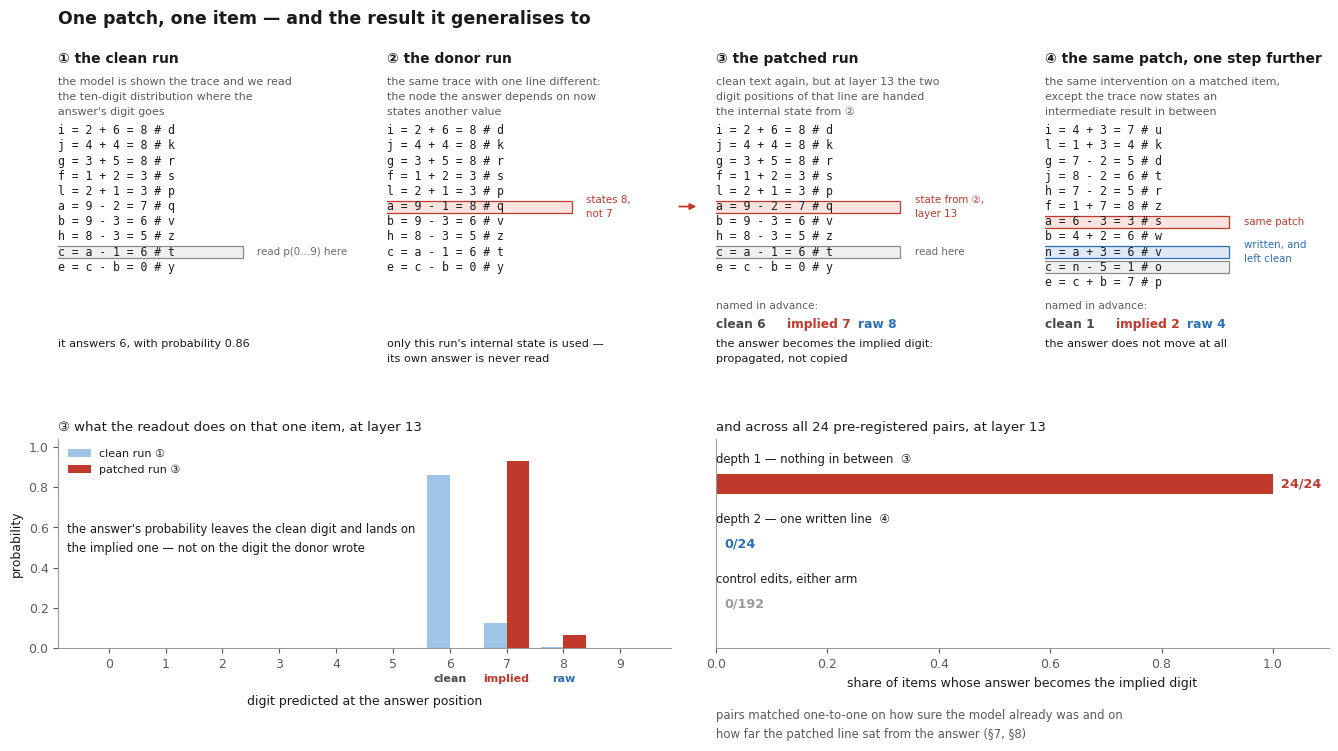

In [2]:
# Figure 1 draws the first item of each pre-registered arm, regenerated from the
# identity that arm stored for it. Generation is deterministic in
# (seed, depth, gap, n_decoys, generator), and the character-level stand-in
# encoder the generator is tested on is enough because only the *text* is drawn
# here -- token positions and distances would need the real tokenizer, so those
# are read from the artifacts instead. Every probability is read, not computed.
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "tests"))
from dag.dag_tasks import generate_items  # noqa: E402
from test_dag_tasks import char_encode  # noqa: E402

PANEL = {}
for depth in (1, 2):
    report = arm(f"e2_stage_b/depth{depth}.json")
    assert report["condition"] == "both"  # the donor line stays arithmetically consistent
    rows = [r for r in report["rows"] if r["kind"] == "ancestor" and r["layer"] == LAYER]
    # Rows carry no item index. They are written item by item -- dag_evidence
    # slices them that way -- and the clean answer sequence is what says so.
    assert [r["clean_value"] for r in rows] == [it["target_value"] for it in report["items"]]
    chosen, row, record = report["selected"][0], rows[0], report["items"][0]
    batch = generate_items(
        char_encode, n_items=chosen["index"] + 1, n_decoys=report["n_decoys"],
        seed=chosen["seed"], condition=report["condition"], depth=chosen["depth"],
        gap=chosen["gap"], generator=report["generator"], omit="none",
    )
    item = batch[chosen["index"]]
    edit = next(e for e in item.edits if e.kind == "ancestor")
    # A regenerated item counts only where it reproduces the archived
    # measurement: the two digits the arm recorded for this item.
    assert item.target_value == row["clean_value"] == record["target_value"]
    assert edit.implied_target_value == row["implied_value"]

    node = item.nodes[edit.node]
    # The donor line, rebuilt: the operand that makes its stated result the raw
    # digit. A donor trace differs from the clean one at the two patched digit
    # positions and nowhere else, so the donor text is the clean text with this
    # one line swapped in.
    operand = (row["raw_value"] - int(node.lhs) if node.op == "+"
               else int(node.lhs) - row["raw_value"])
    lines = item.text.rstrip("\n").split("\n")
    at = next(i for i, line in enumerate(lines) if line.startswith(node.name + " "))
    donor_line = (f"{node.name} = {node.lhs} {node.op} {operand} = {row['raw_value']}"
                  + lines[at][lines[at].index(" #"):])
    assert 0 <= operand <= 9 and len(donor_line) == len(lines[at])
    child = dict(item.edges)
    carried, walk = [], edit.node
    while walk != item.target:
        walk = child[walk]
        carried.append(walk)
    PANEL[depth] = {
        "lines": lines, "donor": [donor_line if i == at else l for i, l in enumerate(lines)],
        "patched": node.name, "answer": item.target, "carried": carried[:-1],
        "row": row, "record": record, "stated": node.value,
    }

BOX = {"patched": ("#fbe3df", COLOR["ancestor"]),
       "carried": ("#dfe9f5", "#2c6fbb"),
       "answer": ("#f0f0f0", "#8a8a8a")}


def card(ax, header, note, panel, lines, boxes, marks=(), named=None, footer=None):
    """One trace, drawn as the model sees it, with the edited lines called out."""
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.text(0, 1.10, header, fontsize=10, fontweight="600", color=INK, va="top")
    ax.text(0, 1.005, note, fontsize=7.9, color=MUTED, va="top", linespacing=1.6)
    top, step = 0.80, 0.058
    at = {}
    for i, line in enumerate(lines):
        y = top - i * step
        name = line.split(" ", 1)[0]
        at[name] = y
        if name in boxes:
            face, edge = BOX[boxes[name]]
            ax.add_patch(Rectangle((-0.03, y - 0.023), 0.68, 0.046, facecolor=face,
                                   edgecolor=edge, lw=0.9, zorder=0))
        ax.text(0, y, line, family="monospace", fontsize=8.3, va="center", color=INK)
    for name, text, color in marks:
        ax.text(0.70, at[name], text, fontsize=7.4, color=color, va="center",
                linespacing=1.5)
    # The three named digits and the one-line reading sit at a fixed height, so
    # the four cards line up even though their traces differ by a line.
    if named:
        ax.text(0, 0.15, "named in advance:", fontsize=7.6, color=MUTED, va="top")
        for i, (label, value, color) in enumerate(named):
            ax.text(i * 0.25, 0.085, f"{label} {value}", fontsize=8.8,
                    color=color, fontweight="600", va="top")
    if footer:
        ax.text(0, 0.005, footer, fontsize=8.1, color=INK, va="top", linespacing=1.6)
    return at


fig = plt.figure(figsize=(13.4, 7.6))
gs = fig.add_gridspec(2, 4, height_ratios=[1.25, 1], hspace=0.42, wspace=0.16,
                      left=0.042, right=0.99, top=0.885, bottom=0.135)
fig.suptitle("One patch, one item — and the result it generalises to",
             x=0.042, y=0.975, ha="left", fontsize=12.5, fontweight="600")

one, two = PANEL[1], PANEL[2]
clean_digit = one["row"]["clean_value"]
implied_digit = one["row"]["implied_value"]
raw_digit = one["row"]["raw_value"]
NAMED = [("clean", clean_digit, "#4b4b4b"), ("implied", implied_digit, COLOR["ancestor"]),
         ("raw", raw_digit, "#2c6fbb")]

CARDS = [fig.add_subplot(gs[0, i]) for i in range(4)]

card(CARDS[0], "① the clean run",
     "the model is shown the trace and we read\nthe ten-digit distribution where the\nanswer's digit goes",
     one, one["lines"], {one["answer"]: "answer"},
     marks=[(one["answer"], "read p(0…9) here", "#6a6a6a")],
     footer=f"it answers {clean_digit}, with probability "
            f"{one['record']['clean_probs'][clean_digit]:.2f}")

donor_at = card(CARDS[1], "② the donor run",
     "the same trace with one line different:\nthe node the answer depends on now\nstates another value",
     one, one["donor"], {one["patched"]: "patched"},
     marks=[(one["patched"], f"states {raw_digit},\nnot {one['stated']}", COLOR["ancestor"])],
     footer="only this run's internal state is used —\nits own answer is never read")

card(CARDS[2], "③ the patched run",
     f"clean text again, but at layer {LAYER} the two\ndigit positions of that line are handed\nthe internal state from ②",
     one, one["lines"], {one["patched"]: "patched", one["answer"]: "answer"},
     marks=[(one["patched"], f"state from ②,\nlayer {LAYER}", COLOR["ancestor"]),
            (one["answer"], "read here", "#6a6a6a")],
     named=NAMED,
     footer="the answer becomes the implied digit:\npropagated, not copied")

card(CARDS[3], "④ the same patch, one step further",
     "the same intervention on a matched item,\nexcept the trace now states an\nintermediate result in between",
     two, two["lines"],
     {two["patched"]: "patched", two["answer"]: "answer",
      **{name: "carried" for name in two["carried"]}},
     marks=[(two["patched"], "same patch", COLOR["ancestor"]),
            (two["carried"][0], "written, and\nleft clean", "#2c6fbb")],
     named=[("clean", two["row"]["clean_value"], "#4b4b4b"),
            ("implied", two["row"]["implied_value"], COLOR["ancestor"]),
            ("raw", two["row"]["raw_value"], "#2c6fbb")],
     footer="the answer does not move at all")

# the one thing the four cards cannot say in words: what moves between them
CARDS[2].annotate("", xy=(-0.06, donor_at[one["patched"]]), xycoords=CARDS[2].transAxes,
                  xytext=(1.02, donor_at[one["patched"]]), textcoords=CARDS[1].transAxes,
                  arrowprops=dict(arrowstyle="-|>", color=COLOR["ancestor"], lw=1.3))

ax = fig.add_subplot(gs[1, 0:2])
digits = list(range(10))
ax.bar([d - 0.2 for d in digits], one["record"]["clean_probs"], width=0.4,
       color=COLOR["clean"], label="clean run ①")
ax.bar([d + 0.2 for d in digits], one["row"]["probs_patched"], width=0.4,
       color=COLOR["patched"], label="patched run ③")
ax.set_xticks(digits)
ax.set_ylim(0, 1.04)
ax.set_xlabel("digit predicted at the answer position", labelpad=17)
ax.set_ylabel("probability")
ax.set_title(f"③ what the readout does on that one item, at layer {LAYER}", loc="left")
ax.legend(fontsize=8, loc="upper left")
for label, value, color in NAMED:
    ax.annotate(label, xy=(value, 0), xytext=(0, -24), textcoords="offset points",
                ha="center", fontsize=8, fontweight="600", color=color,
                annotation_clip=False)
ax.text(0.015, 0.60, "the answer's probability leaves the clean digit and lands on\n"
                     "the implied one — not on the digit the donor wrote",
        transform=ax.transAxes, fontsize=8.4, va="top", linespacing=1.6)

ax = fig.add_subplot(gs[1, 2:4])
spec = {d: STAGE_B["control_specificity"][d]["per_layer"][str(LAYER)] for d in ("1", "2")}
assert {s["control_moved"] for s in spec.values()} == {0}
BARS = [("depth 1 — nothing in between  ③", PRIMARY["hits"]["1"], PRIMARY["n"]["1"], COLOR[1]),
        ("depth 2 — one written line  ④", PRIMARY["hits"]["2"], PRIMARY["n"]["2"], COLOR[2]),
        ("control edits, either arm", 0, spec["1"]["n_control"], "#9a9a9a")]
for y, (label, hits, total, color) in zip((2, 1, 0), BARS):
    ax.barh(y, hits / total, height=0.34, color=color, zorder=2)
    ax.text(0, y + 0.30, label, fontsize=8.4, va="bottom")
    ax.text(hits / total + 0.015, y, f"{hits}/{total}", fontsize=9.2, va="center",
            fontweight="600", color=color)
ax.set_ylim(-0.75, 2.75)
ax.set_yticks([])
ax.set_xlim(0, 1.1)
ax.set_xlabel("share of items whose answer becomes the implied digit")
ax.set_title(f"and across all {PRIMARY['n_pairs']} pre-registered pairs, at layer {LAYER}",
             loc="left")
ax.text(0.0, -0.29, "pairs matched one-to-one on how sure the model already was and on\n"
                    "how far the patched line sat from the answer (§7, §8)",
        transform=ax.transAxes, fontsize=8.4, va="top", linespacing=1.6, color=MUTED)
plt.show()

**Figure 1 — one patch, one item, and the result it generalises to.** ①–③ are the
three runs, on the first item of the pre-registered depth-1 arm. ④ is the first
item of the depth-2 arm: a different item, matched to a depth-1 one on the two
things that travel with depth (§7), whose one structural difference is the blue
line — an intermediate result the trace states, and that the patch leaves clean.
The bar chart is that one item's readout before and after: the clean digit is
emptied and the mass lands on `implied`, the value the donor's number takes after
the recipient's own remaining arithmetic — not on `raw`, the digit the donor
literally wrote at the patched position. That distinction is the whole reason the
three digits are named before the run. The right panel is what those same edits
do across the 24 matched pairs of §8: every depth-1 item, no depth-2 item, and no
control edit at all.

## 2. The design

Four details of that setup do work later.

**Single digits are not cosmetic.** They keep the clean and donor traces
token-aligned at equal length, so a residual state taken at position *p* in the
donor belongs at position *p* in the clean run, and they make the readout a fixed
ten-way choice rather than a comparison of strings.

**Depth is not graph distance.** At depth 1 the answer line reads the patched
node directly. At depth *k* the trace *states* the *k*−1 intermediate results in
between, and those tokens stay clean in the patched run. So the ladder asks:
does a patched internal state still move the answer when a written intermediate
value contradicts it? That is the honest question for a written chain of
thought, and the numbers must not be read as "influence decays with distance" —
the `gap` control in §5 is what separates the two.

**Five row kinds.** Every arm runs the first four; the fifth needs a batch
selected for mutual donatability, so only the cross-item arms have it.

| row kind | what the donor rewrites | what it rules out |
|:---|:---|:---|
| `ancestor` | a node the answer's graph depends on | — this is the effect |
| `non_ancestor` | a matched node off the dependency path | that any node would do |
| `null` | the same positions, the item's own state | that the machinery moves things by itself |
| `surface_null` | a formatting-only rewrite, same token budget | that the notation carries it |
| `cross_item` | another item's state, same positions | that those positions are simply fragile |

**Three named digits, kept apart by construction.** Clean, implied and raw (§1)
are three outcomes only while no two of them coincide. The spine is drawn so the
answer never equals the ancestor's own value, which separates implied from raw;
`v3_distinct` adds the rejection that separates raw from the clean answer, so a
readout that merely copied the token it overwrote could not be mistaken for one
that did nothing. Earlier families lack that second rejection, which is one
reason not every arm may be pooled with every other.

**What is and is not new here.** The intervention is ordinary residual-stream
activation patching, and the ground-truth-graph idea is not new either. Three
things are specific to this setup: the readout distinguishes *propagating* a
value from *copying* a token, because the two predict different digits on every
item; the ladder's axis is the number of written intermediates rather than graph
distance, which is the quantity a chain-of-thought claim actually rests on; and
the depth contrast was pre-registered and re-run under matching after it was
found, which is the step that turned it from a suggestive ladder into a test.
Positioning against the interpretability literature is not written yet —
`RELATED_WORK.md` covers the project's other half.

## 3. The ladder: where the channel reaches

The exploratory ladder pools every `v3_distinct` arm at a **fixed layer 13**,
over items whose clean readout is uniquely correct, with exact-tie readouts held
apart from unique wins. Fixing one layer matters: at layer 20 the same
cross-item rows split 10 implied / 5 raw / 2 clean / 3 other, so a count taken at
each arm's own best layer would mix the effect with the layer choice.

In [3]:
LADDER = pd.DataFrame([
    {
        "patched node": {"ancestor": "ancestor", "cross_item": "another item"}[e["kind"]],
        "depth": e["depth"],
        "seeds": len(e["seeds"]),
        "items": e["n_items"],
        "clean answer right": f"{e['n_clean_correct_unique']}/{e['n_items']}"
                              + (f" (+{e['n_clean_tied']} tied)" if e["n_clean_tied"] else ""),
        "→ implied": f"{e['n_implied_top_unique']}/{e['n_clean_correct_unique']}"
                     + (f" (+{e['n_implied_tied']} tied)" if e["n_implied_tied"] else ""),
        "→ raw": f"{e['n_raw_top_unique']}/{e['n_clean_correct_unique']}",
        "unchanged": f"{e['n_clean_top_unique']}/{e['n_clean_correct_unique']}",
    }
    for e in POOLED["by_kind_and_depth"] if e["omit"] == "none"
])

# The pool is offered every arm and keeps only what it may merge: same
# generator, same readout precision. The refusals are the point, so count both.
kept = {name for m in POOLED["measurements"] for name in m["arms"]}
table(
    LADDER,
    f"Table 1 · where the patched value lands, layer {LAYER}, {POOLED['generator']} pooled",
    highlight=[i == 0 for i in range(len(LADDER))],
    note=(f"{POOLED['n_measurements']} measurements from {len(kept)} of the "
          f"{POOLED['n_arms']} arms offered to the pool — <code>dag_pooling.pool</code> "
          "refuses to merge arms that differ in generator or readout precision, which "
          "is why the float32 stage-B arms of §8 are not in here. Denominators are "
          "items whose clean readout is uniquely correct; bfloat16 puts two digits on "
          "the same 0.125-nat grid point often enough that ties are counted, not "
          "resolved. <b>Layer 13 was chosen by looking at this table</b>, so the "
          "depth-1 rate is not held out — §8 is. The cross-item row is exploratory: "
          "its batch is selected for mutual donatability, so it is not the ladder's "
          "value distribution, and its own specificity gate (§5) clears at no layer "
          "in three of four seeds."),
)

patched node,depth,seeds,items,clean answer right,→ implied,→ raw,unchanged
ancestor,1,4,33,23/33 (+5 tied),21/23 (+2 tied),0/23,0/23
ancestor,2,1,5,5/5,0/5,0/5,5/5
ancestor,3,1,5,5/5,0/5,0/5,5/5
another item,1,4,20,14/20 (+3 tied),11/14 (+3 tied),0/14,0/14


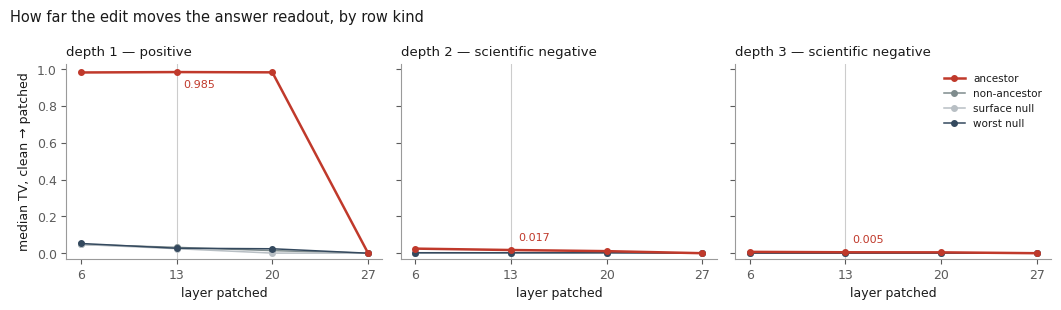

In [4]:
# gates.detail is one record per item per layer, so aggregate it here rather
# than quoting a stored summary.
SERIES = [("tv_ancestor", "ancestor"), ("tv_non_ancestor", "non-ancestor"),
          ("tv_surface_null", "surface null"), ("tv_null_max", "worst null")]

fig, axes = plt.subplots(1, 3, figsize=(10.6, 3.1), sharey=True)
for ax, depth in zip(axes, (1, 2, 3)):
    payload = arm(f"v3_distinct/depth{depth}_gap0.json")
    median = pd.DataFrame(payload["gates"]["detail"]).groupby("layer").median(
        numeric_only=True)
    for column, label in SERIES:
        ax.plot(median.index, median[column], marker="o", ms=4, label=label,
                color=COLOR[label], lw=1.8 if label == "ancestor" else 1.1,
                zorder=3 if label == "ancestor" else 2)
    ax.set_title(f"depth {depth} — {payload['verdict']}", loc="left")
    ax.set_xlabel("layer patched")
    ax.set_xticks(payload["layer_bins"])
    ax.axvline(LAYER, color="#cccccc", lw=0.8, zorder=0)
    at_joint = median.loc[LAYER, "tv_ancestor"]
    ax.annotate(f"{at_joint:.3f}", xy=(LAYER, at_joint), fontsize=8,
                xytext=(5, -11 if at_joint > 0.5 else 7), textcoords="offset points",
                color=COLOR["ancestor"])
axes[0].set_ylabel("median TV, clean → patched")
axes[0].set_ylim(-0.03, 1.03)
axes[-1].legend(fontsize=7.5, loc="upper right")
fig.suptitle("How far the edit moves the answer readout, by row kind", x=0.005,
             ha="left", fontsize=10.5)
fig.tight_layout()
plt.show()

**Figure 2 — the effect is specific, and it is one step deep.** Total variation
between the clean and patched digit distributions, median over items, for the
same five spines at each depth. At depth 1 the ancestor edit rewrites the
readout almost completely (0.985) while every control sits near the floor; at
depth 2 and depth 3 the ancestor line falls onto the controls (0.017 and 0.005).
Two things the panels add to Table 1. First, they show why a *joint* layer had
to be fixed in advance rather than searched per arm: past layer 20 every row
kind decays to zero, because by then there is no downstream computation left to
disturb. Second, the depth-2 and depth-3 arms are **scientific negatives**, not
failed tests — the machinery ran, the controls behaved, the effect was absent.

## 4. What the channel carries: the stated result, not the arithmetic

A consistent donor edit changes an operand *and* its stated result, which sticks
two mechanisms together. Splitting them separates "the model re-derives the value
from the operands" from "the model reads the value it has written".

In [5]:
SPLIT = {"feasibility.json": "both — operand and stated result",
         "result_only.json": "result only — the stated digit changes",
         "operand_only.json": "operand only — the stated digit stays clean"}
rows = []
for name, label in SPLIT.items():
    payload = arm(name)
    frame = pd.DataFrame(payload["rows"])
    at13 = frame[frame["layer"] == LAYER]
    ancestor = at13[at13["kind"] == "ancestor"]
    rows.append({
        "donor edit": label,
        "median TV, ancestor": ancestor["tv"].median(),
        "median TV, non-ancestor": at13[at13["kind"] == "non_ancestor"]["tv"].median(),
        "median Δ log-odds toward implied": ancestor["delta_toward"].median(),
        "verdict": payload["verdict"],
    })
table(
    pd.DataFrame(rows), f"Table 2 · which half of the donor line does the work, layer {LAYER}",
    highlight=[False, True, False],
    note=("The archived pilot: five items, one seed, the <code>v1_unpaired</code> "
          "family, bfloat16, rescored under the current verdict policy. Changing "
          "the written result reproduces the whole consistent effect; changing an "
          "operand and leaving the written result alone does not separate from the "
          "matched non-ancestor. So the propagated quantity in claim 1 is the "
          "donor's <b>stated</b> value. This split has not been rerun on "
          "<code>v3_distinct</code>, and five items is a pilot — it is the weakest "
          "leg of the three claims."),
    **{"median TV, ancestor": "{:.3f}", "median TV, non-ancestor": "{:.3f}",
       "median Δ log-odds toward implied": "{:+.2f}"},
)

donor edit,"median TV, ancestor","median TV, non-ancestor",median Δ log-odds toward implied,verdict
both — operand and stated result,0.844,0.017,+7.13,positive
result only — the stated digit changes,0.837,0.087,+6.83,positive
operand only — the stated digit stays clean,0.078,0.061,+1.10,scientific negative


## 5. Two objections to claim 1

**Proximity.** Maybe the ancestor line simply sits near the read position. The
`gap` control puts decoy lines between the chain and the target, raising token
distance without adding a step to the path — the same five spines at three
placements.

**Fragile positions.** Sharper: maybe those two token positions are
perturbation-sensitive, whatever is written there. Every other edit in the
project rewrites the recipient's *own* trace; the cross-item arm writes
**another item's** state there, same span, same token width, under a derangement
so nothing donates to itself.

In [6]:
rows = []
for gap in (0, 1, 2):
    payload = arm(f"v3_distinct/depth1_gap{gap}.json")
    detail = pd.DataFrame(payload["gates"]["detail"])
    at13 = detail[detail["layer"] == LAYER]
    rows.append({
        "gap": gap,
        "ancestor distance (tokens)": f"{min(payload['ancestor_distance'])}–"
                                      f"{max(payload['ancestor_distance'])}",
        "median TV, ancestor": at13["tv_ancestor"].median(),
        "median TV, worst null": at13["tv_null_max"].median(),
        "answer-moved gate": "pass" if payload["gates"]["answer_moved"]["passes"] else "fail",
        "verdict": payload["verdict"],
    })
table(pd.DataFrame(rows), "Table 3 · the same depth-1 spines at three token distances",
      note=("Distance to the read position more than quadruples and the effect does "
            "not move. These three arms are one spine set at three placements, not "
            "fifteen independent items."),
      **{"median TV, ancestor": "{:.3f}", "median TV, worst null": "{:.3f}"})

rows = []
for seed in range(4):
    gate = arm(f"v3_distinct/cross_seed{seed}.json")["gates"]["cross_item_donor"]
    rows.append({
        "seed": seed,
        "gate measured": str(gate["measured"]),
        "layers it clears": str(gate["layers"]) if gate["layers"] else "none",
        "binds the verdict": str(gate["applied_to_verdict"]),
    })
table(pd.DataFrame(rows), "Table 4 · the cross-item donor gate, four seeds",
      note=("Reported beside the verdict and never folded into it: pulling a new "
            "statistic into a verdict before its null is known is the post-hoc move "
            "two earlier checkpoints were spent undoing. It clears at no layer in "
            "three of four seeds. That is why the cross-item row of Table 1 is "
            "labelled exploratory — <b>this objection is the one the project has not "
            "closed</b>, and it cannot be closed on the pre-registered items either, "
            "since a mutually donatable batch and a depth-matched batch are "
            "different selections."))

gap,ancestor distance (tokens),"median TV, ancestor","median TV, worst null",answer-moved gate,verdict
0,11–24,0.985,0.027,pass,positive
1,24–37,0.991,0.029,pass,positive
2,37–50,0.979,0.092,pass,positive


seed,gate measured,layers it clears,binds the verdict
0,True,none,False
1,True,[6],False
2,True,none,False
3,True,none,False


## 6. The obvious explanation for claim 2 — and why it is not established

If the answer at depth 2 is fixed by the intermediate value the trace has
already written, then removing that written value should let the patch through.
`--omit chain` renders those lines without their results, padded to the exact
same token count, so the graph and every downstream position are unchanged.
`--omit decoy` removes the same number of values from lines the answer does not
depend on, as the control for the notation itself.

In [7]:
ORDER = ["depth1_none", "depth1_chain", "depth2_none", "depth2_decoy", "depth2_chain",
         "depth3_none", "depth3_decoy", "depth3_chain"]
rows = []
for name in ORDER:
    payload = arm(f"written_vs_omitted/{name}.json")
    spec = payload["gates"]["control_specificity"]["per_layer"][str(LAYER)]
    clean = payload["gates"]["clean_answer"]
    share = pd.Series([it["clean_probs"][it["target_value"]] for it in payload["items"]])
    depth, omit = name.replace("depth", "").split("_")
    rows.append({
        "depth": int(depth),
        "values omitted": {"none": "none", "chain": "on the path", "decoy": "off the path"}[omit],
        "clean answer right": f"{clean['n_unique_correct']}/{clean['n_items']}"
                              + (f" (+{clean['n_tied']} tied)" if clean["n_tied"] else ""),
        "median clean p(target)": share.median(),
        "ancestor → implied": f"{spec['ancestor_implied']}/{spec['n_items']}",
        "ancestor moved": f"{spec['ancestor_moved']}/{spec['n_items']}",
        "control rows moved": f"{spec['control_moved']}/{spec['n_control']}",
        "stored verdict": payload["verdict"],
    })
table(pd.DataFrame(rows), f"Table 5 · written versus omitted intermediate results, layer {LAYER}",
      highlight=[r["values omitted"] == "on the path" and r["depth"] > 1 for r in rows],
      **{"median clean p(target)": "{:.3f}"},
      note=("The two tinted rows are the ablation, and they cannot be read. Removing "
            "the values on the path destroys the clean behaviour the test needs — "
            "median clean p(target) falls to 0.240 and 0.050 — while removing the "
            "same count of values off the path leaves the model at 5/5 and 0.997. So "
            "the collapse is the missing dependency, not the <code>#</code> "
            "notation. <b><code>depth2_chain</code>'s stored verdict is "
            "<code>positive</code> and should not be believed:</b> every gate in the "
            "arm scorer is relative, so an arm whose background moves as much as its "
            "ancestor does clears all of them — nulls flip the answer 23/40 there and "
            "33/40 at depth 3, while the ancestor lands on its predicted digit 1/5. "
            "The verdict is left exactly as the scorer produced it; the absolute "
            "diagnostics beside it are what say otherwise."))

depth,values omitted,clean answer right,median clean p(target),ancestor → implied,ancestor moved,control rows moved,stored verdict
1,none,3/5 (+2 tied),0.666,5/5,5/5,4/40,positive
1,on the path,3/5 (+2 tied),0.666,5/5,5/5,4/40,positive
2,none,5/5,0.996,0/5,0/5,0/40,scientific negative
2,off the path,5/5,0.997,0/5,0/5,0/35,scientific negative
2,on the path,2/5,0.240,1/5,4/5,23/40,positive
3,none,5/5,0.999,0/5,0/5,0/40,scientific negative
3,off the path,5/5,0.999,0/5,0/5,0/30,scientific negative
3,on the path,1/5,0.050,0/5,4/5,33/40,scientific negative


So the honest statement of claim 2's mechanism is weaker than "the model does not
compute the intermediate latently". What the arms support is that **no
behaviourally usable carried intermediate was detected** — and a behavioural
failure after removing a written value cannot separate *computing* it from
*retaining* or *retrieving* it in the first place.

## 7. The confound, and the pre-registration

Depth does not travel alone. In the archived runs the eligible clean `p(target)`
supports do not even touch — 0.666–0.961 at depth 1 against 0.966–0.999 at depth
2 — so every depth-1 success is on an item the model was unsure of and every
depth-2 non-effect on one it was sure of, and ancestor distance moves with depth
too. Within depth 1 the rate does not decay with confidence, which is
suggestive but not a test:

In [8]:
BANDS = pd.DataFrame([
    {
        "patched node": {"ancestor": "ancestor", "cross_item": "another item"}[e["kind"]],
        "depth": e["depth"],
        "clean p(target)": f"{e['band'][0]:.1f}–{e['band'][1]:.1f}",
        "items": e["n_items"],
        "→ implied": f"{e['n_implied_top_unique']}/{e['n_items']}"
                     + (f" (+{e['n_implied_tied']} tied)" if e["n_implied_tied"] else ""),
    }
    for e in POOLED["by_confidence_band"] if e["omit"] == "none" and e["n_items"]
])
table(BANDS, f"Table 6 · the ladder split by how sure the model already was, layer {LAYER}",
      note=("Flat inside depth 1 — but every depth-2 and depth-3 item sits in the top "
            "band and no depth-1 item shares it, so nothing in this table separates "
            "depth from confidence. That is what stage A was built to fix."))

patched node,depth,clean p(target),items,→ implied
ancestor,1,0.5–0.8,17,15/17 (+2 tied)
ancestor,1,0.8–1.0,6,6/6
ancestor,2,0.8–1.0,5,0/5
ancestor,3,0.8–1.0,5,0/5
another item,1,0.5–0.8,10,7/10 (+3 tied)
another item,1,0.8–1.0,4,4/4


depth,screened,eligible,clean ties,p(target) min,median,max,ancestor distance
1,630,480,0,0.430,0.707,0.990,11–50
2,600,599,0,0.684,0.992,1.000,23–36


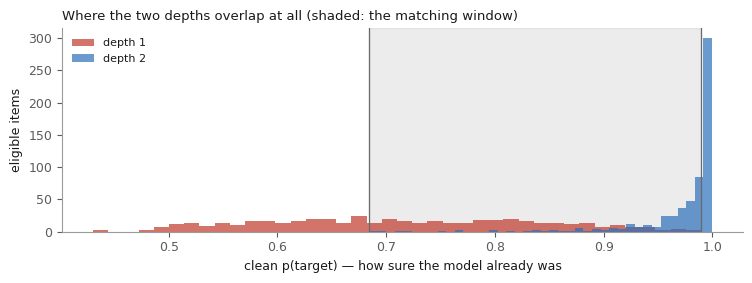

In [9]:
screened = pd.DataFrame(SELECTION["screened"])
sel = SELECTION["selection"]
low, high = sel["window"]

rows = []
for depth, frame in screened.groupby("depth"):
    eligible = frame[frame["clean_correct_unique"]]
    rows.append({
        "depth": depth,
        "screened": len(frame),
        "eligible": len(eligible),
        "clean ties": int(frame["clean_tied"].sum()),
        "p(target) min": eligible["clean_target_share"].min(),
        "median": eligible["clean_target_share"].median(),
        "max": eligible["clean_target_share"].max(),
        "ancestor distance": f"{int(eligible['ancestor_distance'].min())}–"
                             f"{int(eligible['ancestor_distance'].max())}",
    })
pairs = sel["pairs"]
worst_p = max(abs(a["clean_target_share"] - b["clean_target_share"]) for a, b in pairs)
worst_d = max(abs(a["ancestor_distance"] - b["ancestor_distance"]) for a, b in pairs)
table(pd.DataFrame(rows), "Table 7 · stage A — clean forward passes only, no patch anywhere",
      note=(f"Model dtype {screened['readout_dtype'].unique()[0]}. <b>Not one tied "
            "clean readout in 1,230 items</b>, against 5 in 33 under bfloat16. That "
            "is a change of <i>model</i>, not of recording: the dtype reaches "
            "<code>from_pretrained</code>, so every matmul ran at it, while the "
            "readout was float32 in both — <code>digit_readout</code> casts before "
            "it softmaxes. So an archived tie is two <i>bit-identical bfloat16 "
            "logits</i>, which no readout precision could have separated. Window "
            f"[{low:.3f}, {high:.3f}] → <b>{sel['n_pairs']} pairs</b> (floor "
            f"{sel['min_pairs']}, ceiling {sel['max_pairs']}), so the registered "
            f"decision is to proceed. Worst pair: {worst_p:.4f} in clean p(target) "
            f"and {worst_d} token of ancestor distance, over 24 distinct spines per "
            "depth."),
      **{"p(target) min": "{:.3f}", "median": "{:.3f}", "max": "{:.3f}"})

fig, ax = plt.subplots(figsize=(7.6, 2.9))
for depth, frame in screened.groupby("depth"):
    eligible = frame[frame["clean_correct_unique"]]
    ax.hist(eligible["clean_target_share"], bins=40, alpha=0.7, label=f"depth {depth}",
            color=COLOR[depth])
ax.axvspan(low, high, color="#8a8a8a", alpha=0.16, zorder=0)
for edge in (low, high):
    ax.axvline(edge, color="#6a6a6a", lw=0.9)
ax.set_xlabel("clean p(target) — how sure the model already was")
ax.set_ylabel("eligible items")
ax.set_title("Where the two depths overlap at all (shaded: the matching window)",
             loc="left")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**Figure 3 — the confound, measured before anything was patched.** Stage A runs
1,230 clean forward passes and nothing else; there is no patched number in that
directory and no code path in `dag_screening.py` that could produce one, because
it has to decide which items are comparable without having seen how any of them
respond to a patch. The overlap is real but thin, and it sits at the *top* of the
depth-1 range: the matched test is run on the high-confidence half of where the
original depth-1 effect was found — the harder half for claim 1, and the reason a
null result would have been informative. One hole is recorded rather than
patched: the registered rule bounds ancestor distance to ±2 tokens but bounds
confidence only by ordering the greedy match, which on a smaller first screen
filled the ceiling with pairs 0.165 apart. Tripling the screen removed the
problem; on a small screen the hole is still there.

## 8. The pre-registered test

Registered in `6f1e9a7` before the selection rule was written and before any of
these items existed: patch exactly those 24 pairs at layer 13, and read the
implied digit's rate. Nothing in the analysis moved between the stages, and
every item was re-checked against its stage-A measurement — ancestor distance,
target value, gap, and the clean readout to 1e-6 — before being patched.

In [10]:
rows = []
for depth in ("1", "2"):
    validity = STAGE_B["validity"][depth]
    at13 = pd.DataFrame([r for r in arm(f"e2_stage_b/depth{depth}.json")["rows"]
                         if r["layer"] == LAYER])
    median_tv = at13.groupby("kind")["tv"].median()
    rows.append({
        "depth": int(depth),
        "→ implied, uniquely top": f"{PRIMARY['hits'][depth]}/{PRIMARY['n'][depth]}",
        "ancestor rows that moved": f"{validity['ancestor']['flipped']}/{validity['ancestor']['n']}",
        "null rows that flipped": f"{validity['null']['flipped']}/{validity['null']['n']}",
        "median TV, ancestor": median_tv["ancestor"],
        "median TV, worst control": median_tv.drop("ancestor").max(),
        "registered gate": "invalid" if validity["invalid_test"] else "valid",
        "arm scorer verdict": STAGE_B["verdict"][depth],
    })
# The registration names one test, and it turned out degenerate. Two more
# readings of the same 2x2 are quoted beside it, never instead of it: the exact
# paired test the matched design licenses, and Fisher, which does not.
EXACT = PRIMARY["exact_paired"]
fisher = fisher_exact([[PRIMARY["hits"]["1"], PRIMARY["n"]["1"] - PRIMARY["hits"]["1"]],
                       [PRIMARY["hits"]["2"], PRIMARY["n"]["2"] - PRIMARY["hits"]["2"]]],
                      alternative="greater")
assert EXACT["discordant"] == PRIMARY["n_pairs"] and EXACT["against"] == 0
table(pd.DataFrame(rows), f"Table 8 · E2 stage B — matched on confidence and distance, layer {PRIMARY['layer']}",
      highlight=[True, False],
      **{"median TV, ancestor": "{:.3f}", "median TV, worst control": "{:.3f}"},
      note=(f"Difference {PRIMARY['difference']:.2f}, interval "
            f"[{PRIMARY['interval'][0]:.3f}, {PRIMARY['interval'][1]:.3f}] over "
            f"{PRIMARY['replicates']} bootstrap replicates of whole pairs "
            f"(n = {PRIMARY['n_pairs']}); <b>exact paired one-sided "
            f"p = {EXACT['p_value']:.1e}</b> on {EXACT['discordant']} discordant pairs, "
            f"{EXACT['favourable']} for and {EXACT['against']} against. "
            "Row kinds run: " + ", ".join(f"<code>{k}</code>" for k in STAGE_B["row_kinds"])
            + "; unreachable here: "
            + ", ".join(f"<code>{k}</code>" for k in STAGE_B["unreachable_row_kinds"])
            + f". All {PRIMARY['n']['1']} pairs, both arms, are matched to 0.0007 in "
            "clean p(target) and 1 token of ancestor distance. The interval is "
            "degenerate because the separation is perfect, not "
            "because the estimate is precise — zero discordant pairs leaves a "
            "resampler nothing to vary, so read [1.000, 1.000] as <i>no item went the "
            "other way</i>, and quote the exact paired p instead. Fisher's exact on "
            f"the same table gives {fisher.pvalue:.1e}, six orders smaller, by "
            "crediting the design with 48 independent observations where it has 24 "
            "matched pairs. Neither p was registered; the registration named the "
            "bootstrap alone."))

depth,"→ implied, uniquely top",ancestor rows that moved,null rows that flipped,"median TV, ancestor","median TV, worst control",registered gate,arm scorer verdict
1,24/24,24/24,0/144,0.987,0.022,valid,positive
2,0/24,0/24,0/144,0.088,0.008,valid,invalid test


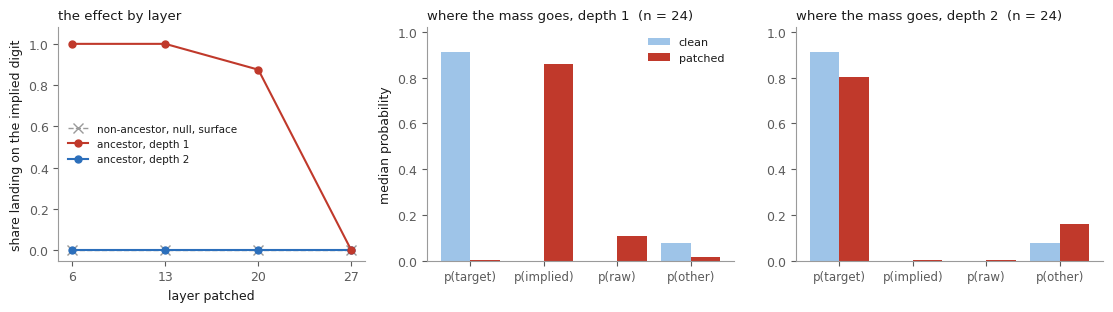

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.2))

ax = axes[0]
LAYERS = sorted(int(k) for k in STAGE_B["control_specificity"]["1"]["per_layer"])
# every control row, at every layer, in both arms -- one number, and it is zero
CONTROLS = {per_layer[str(layer)]["control_moved"] for depth in ("1", "2")
            for per_layer in [STAGE_B["control_specificity"][depth]["per_layer"]]
            for layer in LAYERS}
assert CONTROLS == {0}
ax.plot(LAYERS, [0] * len(LAYERS), marker="x", ms=7, color="#9a9a9a", lw=1.0, ls="--",
        label="non-ancestor, null, surface", zorder=1)
for depth in ("1", "2"):
    per_layer = STAGE_B["control_specificity"][depth]["per_layer"]
    ax.plot(LAYERS, [per_layer[str(layer)]["ancestor_implied"] / per_layer[str(layer)]["n_items"]
                     for layer in LAYERS],
            marker="o", ms=5, color=COLOR[int(depth)], label=f"ancestor, depth {depth}",
            zorder=3 if depth == "1" else 2)
ax.set_ylim(-0.05, 1.08)
ax.set_xticks(LAYERS)
ax.set_xlabel("layer patched")
ax.set_ylabel("share landing on the implied digit")
ax.set_title("the effect by layer", loc="left")
ax.legend(fontsize=7.5, loc="center left")

LEVELS = ["target", "implied", "raw", "other"]
for ax, depth in zip(axes[1:], ("1", "2")):
    split = STAGE_B["level_split"][depth]
    x = range(len(LEVELS))
    ax.bar([i - 0.2 for i in x], [split[k]["clean"] for k in LEVELS], width=0.4,
           label="clean", color=COLOR["clean"])
    ax.bar([i + 0.2 for i in x], [split[k]["patched"] for k in LEVELS], width=0.4,
           label="patched", color=COLOR["patched"])
    ax.set_xticks(list(x))
    ax.set_xticklabels([f"p({k})" for k in LEVELS], fontsize=8.5)
    ax.set_ylim(0, 1.02)
    ax.set_title(f"where the mass goes, depth {depth}  (n = {split['n']})", loc="left")
axes[1].set_ylabel("median probability")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

**Figure 4 — the pre-registered result, and the two places it is untidy.** Left:
the implied digit's share by layer, with every control row flat at zero
throughout (0/192). The effect is already complete at layer 6, holds at 13,
weakens at 20 and is gone at 27 — layer 13 is inherited from Table 1 rather than
re-searched, so this run is confirmatory for the *contrast*, not for the layer.
Middle: at depth 1 the clean answer is emptied and the implied digit takes almost
all of it — but the raw digit is promoted about 200-fold (0.0005 → 0.107) even
though it never wins, so "the recipient transforms the donor value" is a cleaner
sentence than the measurement deserves. Right: at depth 2 the patch is **not
inert, it is unaimed** — its ancestor rows move the readout about twelve times as
far as their worst control (Table 8), but the mass that leaves the clean answer
goes to the *other* digits (0.078 → 0.162) while p(implied) stays at 0.001. The
depth-2 arm carries two labels, both recorded rather than resolved: the registered gate (null flips ≥
20%) calls it valid and negative, while the project's own arm scorer calls it an
*invalid test*, because its gates are relative and at depth 2 there is nothing
for a relative gate to be relative to. They answer different questions; the
registration naming only the null-flip gate is a hole in the registration, not in
the measurement.

## 9. What this establishes, and what it does not

**Establishes.** On this synthetic family, an ancestor-position residual patch
installs the value implied by the recipient's own chain when the answer reads the
patched node directly, and does not when one written intermediate stands in
between; the contrast is not explained by clean confidence or token distance.
What is carried is the donor's *stated* result rather than a recomputation from
its operands (§4, pilot strength). The controls are quiet wherever the clean
readout is stable — non-ancestor, null and surface-null rows leave the answer
alone in every ladder arm and in both stage-B arms. The exception is the two
`chain` omission arms, whose clean behaviour had already collapsed, which is
exactly why their patched numbers are not read as a result.

**Does not.** It does not show *why* depth 2 fails (§6). It says nothing about
MATH-500, about natural traces, or about the 7–8B models the rest of the project
measures — the family is synthetic, the values are single digits, the traces are
teacher-forced and the model is a 1.5B distill. It does not show that the model
represents a causal graph; it recovers one known edge under one intervention. And
it does not connect to the selective-prediction half of the project
([14](14_rmd_paper_story.ipynb)): the two share a question, not an experiment.

**Untouched.** Depth 3 under matching; the cross-item row kind on matched items,
which a mutually donatable batch cannot contain — the registration named it and
stage B could not run it, so that is a protocol deviation, and it is the control
that would show the transplanted state carries content *across* items rather than
within one; the omission arms at any precision above bfloat16; the donor split on
`v3_distinct`; and any layer chosen on data that did not produce the result.

**And one thing the ladder does not isolate.** A step adds an operation, a written
intermediate result, a new variable binding and a changed local context all at
once. §8 matches two observed covariates and removes two rival explanations; it
does not unbundle the rest, so "one step versus two" is the claim and "graph
depth" is not.

## Appendix — every arm, and what may be compared with what

Provenance is part of the claim here, because the package spans a change of
instrument. The archived pilot was taken in bfloat16, whose 0.125-nat digit grid
makes exact two-digit ties ordinary; later runs record their readout dtype; and
three archived arms predate the `depth` / `gap` / distance fields entirely —
those were recovered by regenerating the items and accepted only because the
regenerated items reproduced the archived measurements exactly. Nothing was
backfilled into the original files.

In [12]:
from collections import Counter  # noqa: E402

# A file with rows is a patched arm; everything else in the tree is a manifest,
# a pool, a screening record or an analysis.
ARMS = {}
for path in sorted(DAG.rglob("*.json")):
    with path.open(encoding="utf-8") as handle:
        payload = json.load(handle)
    if isinstance(payload, dict) and "rows" in payload:
        ARMS[str(path.relative_to(DAG))] = payload

WHAT = {
    ".": "the archived pilot — immutable, provenance recovered after the fact",
    "paired_ladder": "the ladder rerun on a family paired across depth",
    "v3_distinct": "ladder and cross-item, all three competing digits kept apart",
    "cross_item": "donor state from another item (earlier generator)",
    "written_vs_omitted": "does writing the intermediate value suppress the patch",
    "e2_stage_b": "the pre-registered matched-pair test",
}


def spread(values):
    # "unrecorded" is a finding here, not a gap to paper over.
    return ", ".join(sorted({"unrecorded" if v is None else str(v) for v in values}))


groups = {}
for name, payload in ARMS.items():
    groups.setdefault(str(Path(name).parent), []).append(payload)

rows = []
for family in ["."] + sorted(k for k in groups if k != "."):
    payloads = groups[family]
    verdicts = Counter(p["verdict"] for p in payloads)
    rows.append({
        "family": family if family != "." else "(archived)",
        "what it is": WHAT[family],
        "arms": len(payloads),
        "items": spread(p["n_items"] for p in payloads),
        "generator": spread(p.get("generator") for p in payloads),
        "readout": spread(p.get("readout_dtype") for p in payloads),
        "depth": spread(p.get("depth") for p in payloads),
        "verdicts": ", ".join(f"{k} ×{n}" for k, n in sorted(verdicts.items())),
    })
table(pd.DataFrame(rows), f"Table 9 · {len(ARMS)} patched arms in {len(groups)} families",
      note=("Verdicts are a policy over the stored rows and are rescored, never hand "
            "edited, so the counts here move when the policy does. Precision is the "
            "reason the pool in Table 1 is smaller than this inventory: "
            "<code>dag_pooling.pool</code> will not put a change of instrument into a "
            "numerator."))

family,what it is,arms,items,generator,readout,depth,verdicts
(archived),"the archived pilot — immutable, provenance recovered after the fact",8,5,unrecorded,unrecorded,"1, 2, 3, unrecorded","positive ×7, scientific negative ×1"
cross_item,donor state from another item (earlier generator),4,5,v2_paired,unrecorded,1,positive ×4
e2_stage_b,the pre-registered matched-pair test,2,24,v3_distinct,float32,"1, 2","invalid test ×1, positive ×1"
paired_ladder,the ladder rerun on a family paired across depth,5,5,v2_paired,unrecorded,"1, 2, 3",positive ×5
v3_distinct,"ladder and cross-item, all three competing digits kept apart",9,5,v3_distinct,unrecorded,"1, 2, 3","positive ×7, scientific negative ×2"
written_vs_omitted,does writing the intermediate value suppress the patch,8,5,v3_distinct,unrecorded,"1, 2, 3","positive ×3, scientific negative ×5"


### Reproducing any row above

```
# one arm of the ladder
uv run python dag/dag_patching.py --generator v3_distinct \
  --condition both --seed 0 --n_items 5 --depth 1 --gap 0 \
  --output results/dag_patching/v3_distinct/depth1_gap0.json

# the selection, which runs no model and is re-derivable from the screened records
uv run python dag/dag_screening.py --depths 1 2 \
  --screened results/dag_patching/e2_screening/depth{1,1_more,2,2_more}.json \
  --output results/dag_patching/e2_screening/SELECTION.json

# the pre-registered arms, which patch exactly the pairs that selection chose
uv run python dag/dag_stage_b.py \
  --selection results/dag_patching/e2_screening/SELECTION.json \
  --n_decoys 6 --output_dir results/dag_patching/e2_stage_b
```

Each results directory carries a `README.md` with the command as it was run, the
run commit and what the arm is for — those predate the move of these scripts
under `dag/`, and the flags are unchanged. `dag/dag_pooling.py` builds
`POOLED.json` and is the only thing that decides what may be merged with what;
`dag_patching.py --rescore` re-derives a verdict from stored rows without a
GPU, which is what makes claim 3 checkable rather than a promise.